# A Complex Experiment: autqec Transversal Gates + Homological Measurement + LR-Circuit Extraction

This notebook shows how a few EPIC building blocks compose into a non-trivial experiment with very little code:

1. **Code**: a Steane `[[7,1,3]]` CSS code, built directly from its parity-check matrix.
2. **`autqec` transversal gate**: we let `autqec` search the code's automorphism group and pick the one that implements a transversal logical Hadamard, then wrap it in EPIC's `AutQecTransversal` gadget.
3. **Homological measurement**: three Steane patches (control, target, ancilla) are wired into a logical CNOT using two `HomologicalMeasurement` gadgets (an M`ZZ` and an M`XX`), the standard ancilla-mediated teleportation construction.
4. **LR-circuit syndrome extraction**: instead of a hand-designed extraction circuit, every patch is measured using `LRCircuit`, which automatically colours and orders the syndrome-extraction CNOTs for an arbitrary CSS code [Strikis, Browne & Beverland, 2026].

Each piece is compiled with the same `QECCompiler`, showing that gadgets, gates and primitives are interchangeable parts of one program.


In [1]:
import numpy as np
import stim

from autqec.graph_auts import valid_clifford_auts_B_rows
from autqec.automorphisms import circ_from_aut, logical_circ_and_pauli_correct

from epic import (
    AllocCode,
    FreeCode,
    InitCode,
    PauliChar,
    PauliEigenState,
    PauliString,
    QECCompiler,
    QProgOperation,
    QuantumProgram,
    ReadoutCode,
    StimLikeNoiseModel,
)
from epic.modules.stabilizers_codes.css_code import CSSCode
from epic.modules.qec_gadgets.transversal_gates.autqec_transversal import AutQecTransversal
from epic.modules.qec_gadgets.pauli_product_measurement.homological_measurement import HomologicalMeasurement

print("Imports OK")


Imports OK


## 1) A nice code: Steane `[[7,1,3]]`, plus one compiler config for everything

The same `compiler_config` below is reused for both experiments in this notebook: gate application and readout use the simple, generic primitives, while syndrome extraction is delegated to `LRCircuit`, which works for any CSS code (not just surface-code-shaped ones).


In [2]:
H_steane = np.array(
    [[0, 0, 0, 1, 1, 1, 1],
     [0, 1, 1, 0, 0, 1, 1],
     [1, 0, 1, 0, 1, 0, 1]],
    dtype=np.uint8,
)
lX = lZ = [1, 1, 1, 0, 0, 0, 0]


def make_steane(code_name: str) -> CSSCode:
    return CSSCode.from_css_pcm(code_name=code_name, hx=H_steane, hz=H_steane, logical_qubits=[(lX, lZ)])


compiler_config = {
    "objective_distance": 3,
    "primitives": {
        "epic.core.qec_primitives.interfaces.ApplyGate": "epic.modules.qec_primitives.apply_gates.simple_gate_application.SimpleGateApplication",
        "epic.core.qec_primitives.interfaces.Readout": "epic.modules.qec_primitives.readouts.naive_readout.NaiveReadout",
        "epic.core.qec_primitives.interfaces.ExtractSyndrome": "epic.modules.qec_primitives.syndrome_extraction.lr_circuit.LRCircuit",
    },
}

print(f"Steane code: n={make_steane('probe').n}, k={make_steane('probe').k}, d={make_steane('probe').d}")


Steane code: n=7, k=1, d=3


## 2) Let `autqec` find a transversal logical Hadamard

`autqec.graph_auts.valid_clifford_auts_B_rows` searches the code's automorphism group. We keep the one automorphism whose logical action is a single-qubit `H`, then convert its circuit and check-permutation into the fields required by EPIC's `AutQecTransversal` gadget (helper functions adapted from `autqec_integration.ipynb`).


In [3]:
control_code = make_steane("control")

pcm_symp, var_nodes, check_nodes = control_code.tanner_graph.parity_check_matrix
H_symp = pcm_symp.toarray().astype(np.uint8)
n = H_symp.shape[1] // 2
H_3bit = np.hstack([H_symp, (H_symp[:, :n] + H_symp[:, n:]) % 2])

auts = valid_clifford_auts_B_rows(H_3bit, bits_3=True, return_order=False)


def logical_action_of(aut):
    phys_act = circ_from_aut(H_symp, aut)
    phys_circ_raw, symp_mat = phys_act.circ()
    logical_act = logical_circ_and_pauli_correct(H_symp, phys_circ_raw)
    logical_circ, _ = logical_act.run()
    return logical_circ, phys_circ_raw, symp_mat


# Keep the automorphism whose logical action is a bare Hadamard on the single logical qubit.
selected_aut = next(aut for aut in auts if logical_action_of(aut)[0] == [("H", 1)])
logical_circ, phys_circ_raw, symp_mat = logical_action_of(selected_aut)
print(f"Automorphisms found: {len(auts)}; selected logical action: {logical_circ}")


Automorphisms found: 3; selected logical action: [('H', 1)]


In [4]:
def derive_detector_check_map_idx(H_symp_local, S):
    S = np.asarray(S, dtype=np.uint8) % 2
    H_trans = (H_symp_local @ S) % 2
    target = {tuple(int(v) for v in row.tolist()): i for i, row in enumerate(H_symp_local)}
    mapping = {}
    for i, row in enumerate(H_trans):
        sig = tuple(int(v) for v in row.tolist())
        mapping[i] = [target[sig]]
    return mapping


def autqec_circuit_to_gadget_fields(phys_circ, var_nodes_local, check_nodes_local, det_map_idx):
    single_qubit_gates = []
    swaps = []
    two_qubit = {"CNOT", "CX", "CZ", "ISWAP"}

    for op in phys_circ:
        if not isinstance(op, (list, tuple)) or len(op) < 2:
            continue
        gate = str(op[0]).replace("SQRT-X", "SQRT_X")
        raw = op[1] if len(op) == 2 else tuple(op[1:])
        if isinstance(raw, np.ndarray):
            raw = raw.flatten().tolist()
        if isinstance(raw, (list, tuple)):
            flat = []
            for target in raw:
                if isinstance(target, (list, tuple, np.ndarray)):
                    flat.extend(int(index) for index in np.asarray(target).reshape(-1))
                else:
                    flat.append(int(target))
        else:
            flat = [int(raw)]

        # autqec uses 1-based indices.
        if gate == "SWAP" and len(flat) >= 2:
            swaps.append((var_nodes_local[flat[0] - 1], var_nodes_local[flat[1] - 1]))
        elif gate in two_qubit:
            for index in range(0, len(flat) - 1, 2):
                single_qubit_gates.append((gate, var_nodes_local[flat[index] - 1]))
                single_qubit_gates.append((gate, var_nodes_local[flat[index + 1] - 1]))
        else:
            for index in flat:
                single_qubit_gates.append((gate, var_nodes_local[index - 1]))

    detector_check_map = {
        check_nodes_local[int(current)]: tuple(check_nodes_local[int(previous)] for previous in previous_nodes)
        for current, previous_nodes in det_map_idx.items()
    }
    return single_qubit_gates, swaps, detector_check_map


det_map_idx = derive_detector_check_map_idx(H_symp, symp_mat)
single_qubit_gates, swaps, detector_check_map = autqec_circuit_to_gadget_fields(
    phys_circ_raw, var_nodes, check_nodes, det_map_idx
)

logical_H_gadget = AutQecTransversal(
    targets=["control_patch"],
    single_qubit_gates=single_qubit_gates,
    swaps=swaps,
    detector_check_map=detector_check_map,
    tag="logical_H",
)
print(f"Transversal gadget ready: {len(single_qubit_gates)} single-qubit gates, {len(swaps)} swaps.")


Transversal gadget ready: 7 single-qubit gates, 0 swaps.


## 3) Run the transversal gate through the LR-circuit extraction primitive

We prepare the logical `0`, apply the transversal `H`, and read out in the `X` basis (the basis the state now lives in). Under the LR-circuit syndrome extraction, the outcome should still be deterministic.


In [5]:
gate_program = QuantumProgram(name="transversal_H_via_lr_circuit")
gate_qubit = gate_program.add_qubit(
    AllocCode(target_code=control_code, code_varname="control_patch", logical_qubits_varnames=["q"])
)
gate_program.add_operations([
    QProgOperation(
        name="init",
        length=1,
        targets=[gate_qubit],
        implementation=InitCode(targets=["control_patch"], initial_state=PauliEigenState.Z_plus),
    ),
    QProgOperation(name="logical_H", length=1, targets=[gate_qubit], implementation=logical_H_gadget),
    QProgOperation(
        name="readout",
        length=1,
        targets=[gate_qubit],
        implementation=ReadoutCode(targets=["control_patch"], readout_basis=PauliChar.X, tag="out"),
    ),
    QProgOperation(name="free", length=0, targets=[gate_qubit], implementation=FreeCode(code_varname="control_patch")),
])

compiled_gate_program = QECCompiler(config=compiler_config).compile(gate_program)
gate_observable = next(o.tag for o in compiled_gate_program.observables if o.tag.startswith("readout_out"))

noisy_gate_circuit = stim.Circuit(
    compiled_gate_program.to_stim_program(
        [[gate_observable]],
        noise_model=StimLikeNoiseModel.from_stim_like_probabilities(
            after_clifford_depolarization=1e-3,
            after_reset_flip_probability=1e-3,
            before_measure_flip_probability=1e-3,
        ),
    )
)
noiseless_gate_circuit = stim.Circuit(
    compiled_gate_program.to_stim_program(
        [[gate_observable]],
        noise_model=StimLikeNoiseModel.from_stim_like_probabilities(),
    )
)
_, observed = noiseless_gate_circuit.compile_detector_sampler().sample(50, separate_observables=True)

print(f"Detectors: {len(compiled_gate_program.detectors)}, observable: {gate_observable}")
print("Noiseless outcome is deterministic:", (observed == observed[0]).all())
print("Graphlike distance of the compiled circuit:", len(noisy_gate_circuit.shortest_graphlike_error(ignore_ungraphlike_errors=True)))


Colours used for left Hx: 3
Colours used for right Hx: 3
Colours used for left Hz: 3
Colours used for right Hz: 3
CNOT depth for the LR circuit: 6
Evaluating residual distances using BPOSD. Depending on the number of residuals and attempts set, this may take a while.
Number of workers: 10
Calculating residual distances for X stabilisers 1 to 3 out of 3
Calculating residual distances for Z stabilisers 1 to 3 out of 3
DONE
--------------------------------------------
Evaluating colour permutations for X stabilisers...
Found a total of 36 colour permutations.
  New residual profile: [0 0 3 6]
Final residual profile: [0 0 3 6]
Lowest residual distance found: 2
Ancilla idling time of the best colouring: 2
--------------------------------------------
Evaluating colour permutations for Z stabilisers...
Found a total of 36 colour permutations.
  New residual profile: [0 0 3 6]
  New ancilla idling time: 2
Final residual profile: [0 0 3 6]
Lowest residual distance found: 2
Ancilla idling time o

## 4) A logical CNOT from two homological measurements

Three independent Steane patches (`control`, `target`, `ancilla`) are wired into a logical CNOT by the standard ancilla-mediated teleportation: an M`ZZ` between control and ancilla, followed by an M`XX` between ancilla and target. All three patches are extracted with `LRCircuit`. The program is compiled **once**; noise is only applied when converting to a Stim circuit, so sweeping the physical error rate below is cheap.


In [6]:
target_code = make_steane("target")
ancilla_code = make_steane("ancilla")

cnot_program = QuantumProgram(name="homological_cnot")
control_q = cnot_program.add_qubit(
    AllocCode(target_code=control_code, code_varname="control_patch", logical_qubits_varnames=["control"])
)
target_q = cnot_program.add_qubit(
    AllocCode(target_code=target_code, code_varname="target_patch", logical_qubits_varnames=["target"])
)
ancilla_q = cnot_program.add_qubit(
    AllocCode(target_code=ancilla_code, code_varname="ancilla_patch", logical_qubits_varnames=["ancilla"])
)

cnot_program.add_operations([
    QProgOperation(
        name="init_control", length=1, targets=[control_q],
        implementation=InitCode(targets=["control_patch"], initial_state=PauliEigenState.Z_plus),
    ),
    QProgOperation(
        name="init_target", length=1, targets=[target_q],
        implementation=InitCode(targets=["target_patch"], initial_state=PauliEigenState.Z_plus),
    ),
    QProgOperation(
        name="init_ancilla", length=1, targets=[ancilla_q],
        implementation=InitCode(targets=["ancilla_patch"], initial_state=PauliEigenState.X_plus),
    ),
    QProgOperation(
        name="MZZ_control_ancilla", length=1, targets=[control_q, ancilla_q],
        implementation=HomologicalMeasurement(
            targets=["control", "ancilla"], product_to_measure=PauliString(string=(PauliChar.Z, PauliChar.Z)), tag="MZZ_ca",
        ),
    ),
    QProgOperation(
        name="MXX_ancilla_target", length=1, targets=[ancilla_q, target_q],
        implementation=HomologicalMeasurement(
            targets=["ancilla", "target"], product_to_measure=PauliString(string=(PauliChar.X, PauliChar.X)), tag="MXX_at",
        ),
    ),
    QProgOperation(name="readout_control", length=1, targets=[control_q], implementation=ReadoutCode(targets=["control_patch"], tag="control")),
    QProgOperation(name="readout_ancilla", length=1, targets=[ancilla_q], implementation=ReadoutCode(targets=["ancilla_patch"], tag="ancilla")),
    QProgOperation(name="readout_target", length=1, targets=[target_q], implementation=ReadoutCode(targets=["target_patch"], tag="target")),
    QProgOperation(name="free_control", length=0, targets=[control_q], implementation=FreeCode(code_varname="control_patch")),
    QProgOperation(name="free_target", length=0, targets=[target_q], implementation=FreeCode(code_varname="target_patch")),
    QProgOperation(name="free_ancilla", length=0, targets=[ancilla_q], implementation=FreeCode(code_varname="ancilla_patch")),
])

compiled_cnot_program = QECCompiler(config=compiler_config).compile(cnot_program)

# Feedforward convention: control is unaffected; target is corrected by the MZZ outcome and the ancilla readout.
cnot_observables = [
    ["readout_control_control_lq_0"],
    ["hm_PP_MZZ_ca", "readout_ancilla_ancilla_lq_0", "readout_target_target_lq_0"],
]


def cnot_circuit(noise: float) -> stim.Circuit:
    noise_model = StimLikeNoiseModel.from_stim_like_probabilities(
        after_clifford_depolarization=noise,
        after_reset_flip_probability=noise,
        before_measure_flip_probability=noise,
    )
    return stim.Circuit(compiled_cnot_program.to_stim_program(cnot_observables, noise_model=noise_model))


_, observed = cnot_circuit(0).compile_detector_sampler().sample(50, separate_observables=True)
print("Noiseless CNOT outcome is deterministic:", (observed == observed[0]).all())
print("Graphlike distance at p=1e-3:", len(cnot_circuit(1e-3).shortest_graphlike_error(ignore_ungraphlike_errors=True)))


Colours used for left Hx: 3
Colours used for right Hx: 3
Colours used for left Hz: 3
Colours used for right Hz: 3
CNOT depth for the LR circuit: 6
Evaluating residual distances using BPOSD. Depending on the number of residuals and attempts set, this may take a while.
Number of workers: 10
Calculating residual distances for X stabilisers 1 to 3 out of 3
Calculating residual distances for Z stabilisers 1 to 3 out of 3
DONE
--------------------------------------------
Evaluating colour permutations for X stabilisers...
Found a total of 36 colour permutations.
  New residual profile: [0 0 3 6]
  New ancilla idling time: 2
Final residual profile: [0 0 3 6]
Lowest residual distance found: 2
Ancilla idling time of the best colouring: 2
--------------------------------------------
Evaluating colour permutations for Z stabilisers...
Found a total of 36 colour permutations.
  New residual profile: [0 0 3 6]
Final residual profile: [0 0 3 6]
Lowest residual distance found: 2
Ancilla idling time o

## 5) Benchmark the logical CNOT's error rate

Sweep the physical noise, decode with BP+OSD, and plot the logical error rate of the corrected target observable.


Starting 10 workers...
5 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                        
        2   bposd   ?       5000         100 code=steane_homological_cnot,p=0.0001                
        2   bposd   ?       5000         100 code=steane_homological_cnot,p=0.00031622776601683794
        2   bposd  2m       4999         100 code=steane_homological_cnot,p=0.001                 
        2   bposd   ?       5000         100 code=steane_homological_cnot,p=0.0031622776601683794 
        2   bposd   ?       5000         100 code=steane_homological_cnot,p=0.01                  
5 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                        
        2   bposd <1m       4854          98 code=steane_homological_cnot,p=0.0001                
        2   bposd <1m       4854          97 code=steane_homological_cnot,p=0.00031622776601683794
        2   bposd <1m       4982         100 code=steane_h

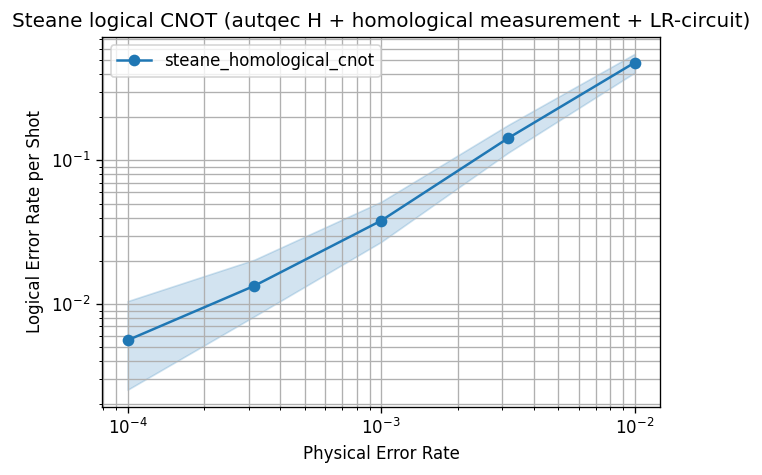

In [7]:
import sinter
from ldpc.sinter_decoders import SinterBpOsdDecoder
from matplotlib import pyplot as plt

plt.set_loglevel("warning")


def generate_tasks():
    for noise in np.geomspace(1e-4, 1e-2, 5):
        yield sinter.Task(
            circuit=cnot_circuit(noise),
            json_metadata={"code": "steane_homological_cnot", "p": float(noise)},
        )


collected_stats = sinter.collect(
    num_workers=10,
    max_shots=5_000,
    max_errors=100,
    tasks=generate_tasks(),
    decoders=["bposd"],
    custom_decoders={
        "bposd": SinterBpOsdDecoder(max_iter=5, bp_method="ms", ms_scaling_factor=0.625, schedule="parallel", osd_method="OSD_0"),
    },
    print_progress=True,
)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    group_func=lambda stat: stat.json_metadata["code"],
    x_func=lambda stat: stat.json_metadata["p"],
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Steane logical CNOT (autqec H + homological measurement + LR-circuit)")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)


## 6) Visualize the code and the compiled program

EPIC ships two Matplotlib-based visualizers: `TannerGraphVisualizer` draws a code's Tanner graph (with optional highlights for logical operators, detectors, etc.), and `draw_quantum_program` renders a `QuantumProgram` as a time-versus-qubit schedule.


(<Figure size 900x1000 with 1 Axes>,
 <Axes: title={'center': 'Steane code Tanner graph with logical operators'}>)

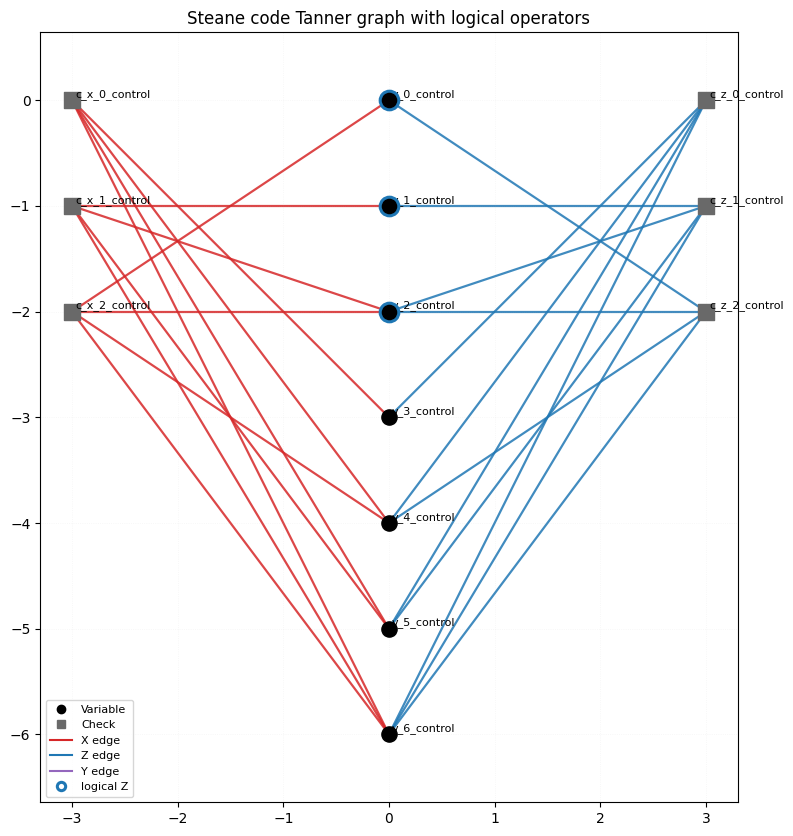

In [8]:
from epic.core.visualization.tanner_graph_vis import TannerGraphVisualizer

logical_qubit = control_code.logical_qubits[0]
TannerGraphVisualizer.visualize(
    control_code.tanner_graph,
    highlight_nodes=[
        ({n.id for n in logical_qubit.logical_x.target_nodes}, "tab:red", "logical X"),
        ({n.id for n in logical_qubit.logical_z.target_nodes}, "tab:blue", "logical Z"),
    ],
    title="Steane code Tanner graph with logical operators",
)


(<Figure size 1000x375 with 1 Axes>,
 <Axes: title={'center': 'Homological-measurement CNOT: control / target / ancilla schedule'}, xlabel='Time', ylabel='Qubit'>)

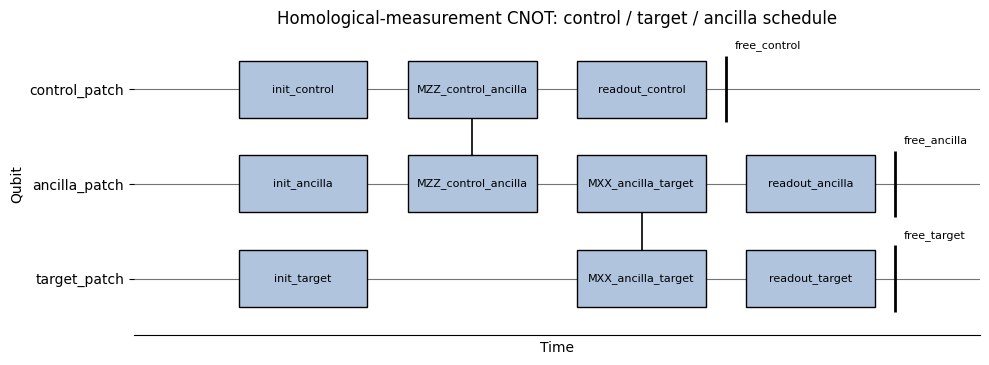

In [9]:
from epic.core.visualization.quantum_program_vis import draw_quantum_program

draw_quantum_program(cnot_program, title="Homological-measurement CNOT: control / target / ancilla schedule")


## 7) Visualize the final compiled circuit

`compiled_cnot_program.program` is the compiled output itself: a `QuantumProgram` expressed entirely in physical qubits, after every gadget and primitive has been expanded. `draw_quantum_program` renders that physical-qubit schedule directly, and Stim can also render the same compiled circuit as a timeline diagram and as a detector-slice diagram of one round of the LR-circuit syndrome extraction.


In [12]:
draw_quantum_program(
    compiled_cnot_program.program,
    title="Compiled homological-measurement CNOT (physical qubits)",
)


(<Figure size 69980x3750 with 1 Axes>,
 <Axes: title={'center': 'Compiled homological-measurement CNOT (physical qubits)'}, xlabel='Time', ylabel='Qubit'>)

In [13]:
print("gate program ops/depth:", len(compiled_gate_program.program.operations), max(s + op.length for op, s in compiled_gate_program.program.operations))
print("cnot program ops/depth:", len(compiled_cnot_program.program.operations), max(s + op.length for op, s in compiled_cnot_program.program.operations))


gate program ops/depth: 281 66
cnot program ops/depth: 1849 266


In [ ]:
fig, ax = draw_quantum_program(compiled_gate_program.program, title="probe")
print(fig.get_size_inches())


### Summary

Three independently-developed EPIC components — an `autqec`-discovered transversal gate, homological-measurement-based lattice surgery, and the automated `LRCircuit` syndrome extractor — were composed into one experiment by writing a single `QuantumProgram` and compiling it once with `QECCompiler`. No component needed to know about the others; each is just a gadget or a primitive implementation plugged into the same compiler config.
